In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np

In [86]:
path = '/home/haitong/PycharmProjects/lvrep-rl-cloned/log'
noise_levels = [0.0, 1.0, 2.0, 3.0]
dfs = []
for env in sorted(os.listdir(path)):
    if os.path.isdir(os.path.join(path, env)) and env.startswith('Pendulum-v1_'):
        env_path = os.path.join(path, env)
        for algo in os.listdir(env_path):
           algo_path = os.path.join(env_path, algo)
           exp = os.listdir(algo_path)[0]
           df = pd.read_csv(os.path.join(algo_path, exp, 'log.csv'))
           sliced_df = df[df['step']==80000]
           sliced_df['noise'] = env.split('sigma_')[1][:3]
           if algo.startswith('sac'):
               sliced_df['algo'] = 'SAC'
           elif algo.startswith('rfsac_nystrom_False'):
               sliced_df['algo'] = 'SDEC (RF)'
           elif algo.startswith('rfsac_nystrom_True'):
               sliced_df['algo'] = 'SDEC (Nystrom)'
           dfs.append(sliced_df)
           
total_df = pd.concat(dfs, ignore_index=True)
print(total_df)

     step      avg_ret     std_ret noise            algo
0   80000  -247.741742  169.294823   0.0             SAC
1   80000  -788.122589  427.126791   0.0  SDEC (Nystrom)
2   80000  -245.578495  175.608666   0.0       SDEC (RF)
3   80000  -459.292816  211.652430   1.0             SAC
4   80000  -395.426431  186.367168   1.0  SDEC (Nystrom)
5   80000  -403.593451  169.735771   1.0       SDEC (RF)
6   80000  -729.488585  142.848931   2.0             SAC
7   80000 -1165.364364  102.952454   2.0  SDEC (Nystrom)
8   80000  -703.842714  141.385046   2.0       SDEC (RF)
9   80000  -847.023253  112.000488   3.0             SAC
10  80000 -1184.029010  114.166491   3.0  SDEC (Nystrom)
11  80000  -820.812659  120.777356   3.0       SDEC (RF)


/tmp/ipykernel_4006359/493063625.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sliced_df['noise'] = env.split('sigma_')[1][:3]
/tmp/ipykernel_4006359/493063625.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sliced_df['algo'] = 'SAC'
/tmp/ipykernel_4006359/493063625.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

In [ ]:
nonlinear_control_df = {
    'avg_ret': [-1090, -1050, -844, -805, -1084, -1331, ],
    'std_ret': [36, 25, 620, 631],
    'step': [80000, 80000, 80000, 80000, 80000, 80000, 80000, 80000, ],
    'algo': ['DKUC', 'DKUC', 'DKUC', 'DKUC', 'iLQR', 'iLQR', 'iLQR', 'iLQR', ],
    'noise': [0.0, 1.0, 2.0, 3.0, 0.0, 1.0, 2.0, 3.0, ],
    
}

-0.4 -245.57849478353924
0.6 -403.5934510880286
1.6 -703.8427143594474
2.6 -820.8126586110742
-0.13333333333333333 -788.122589055347
0.8666666666666667 -395.4264305516954
1.8666666666666667 -1165.3643641759177
2.8666666666666667 -1184.02900959157
0.13333333333333328 -247.7417415897472
1.1333333333333333 -459.2928164645304
2.1333333333333333 -729.4885847886316
3.1333333333333333 -847.0232531302413


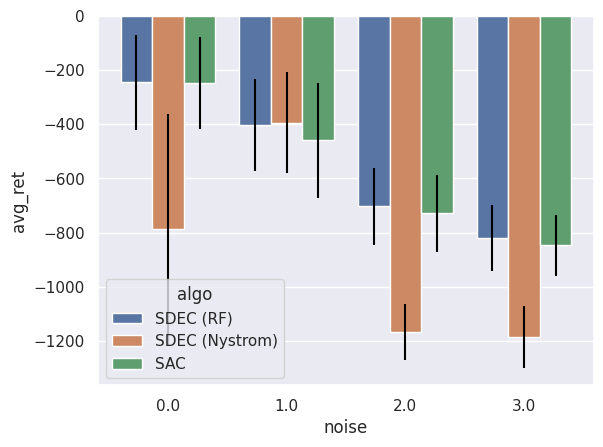

In [87]:
hue_order = ['SDEC (RF)', 'SDEC (Nystrom)', 'SAC']
ax = sns.barplot(x='noise', y='avg_ret', hue='algo', data=total_df, hue_order=hue_order)
for i, bar in enumerate(ax.patches):
    if i < 12:
        alg_index = i // 4
        alg = hue_order[alg_index]
        print(bar.get_x(), bar.get_height())
        ax.errorbar(bar.get_x() + bar.get_width() / 2, bar.get_height(), total_df[total_df['algo'] == alg]['std_ret'].iloc[i % 4],
                    color='black')

ValueError: The value for `errorbar` must be one of ['ci', 'pi', 'se', 'sd'], but None was passed.

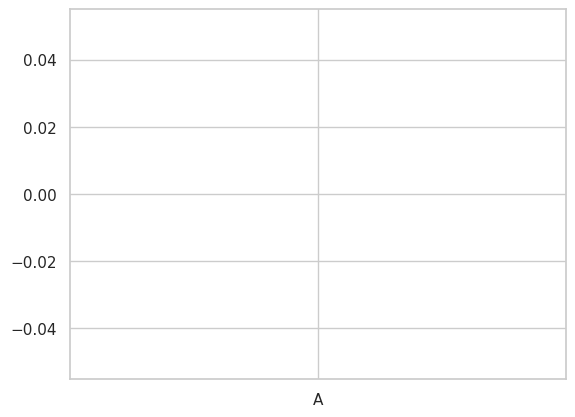

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Sample data
data = pd.DataFrame({
    "category": ["A", "B", "C"],
    "value": [10, 15, 7]
})

# Manually set error values
error_values = [2, 1.5, 3]  # Errors for A, B, and C

# Using Seaborn's barplot with custom error values
sns.barplot(
    data=data,
    x="category",
    y="value",
    errorbar=(None, error_values),  # Custom error bars
    capsize=0.2                     # Add caps to the error bars
)

plt.show()
